# 01 — Data Cleaning

**Project:** Customer Segmentation (RFM + K-means)
**Data:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii) — transactions from a UK-based online retailer, Dec 2009 to Dec 2011.

**Goal of this notebook:** turn raw transactions into a clean dataset where every row is a real purchase made by an identified customer. Each cleaning step is logged, so we know exactly how many rows are removed and why.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
DATA_DIR = Path("../data")

## 1. Loading the data

The Excel file contains two sheets (one per year). Reading an `.xlsx` file this large takes one to two minutes, so we read it **once** and save a CSV copy that loads much faster.

In [19]:
raw_csv = DATA_DIR / "online_retail_II_raw.csv"

if raw_csv.exists():
    df_raw = pd.read_csv(raw_csv, dtype={"Invoice": str, "StockCode": str},
                         parse_dates=["InvoiceDate"])
else:
    sheets = pd.read_excel(DATA_DIR / "online_retail_II.xlsx", sheet_name=None,
                           dtype={"Invoice": str, "StockCode": str})
    df_raw = pd.concat(sheets.values(), ignore_index=True)
    df_raw.to_csv(raw_csv, index=False)

print(df_raw.shape)
df_raw.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 2. First look

In [20]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  str           
 1   StockCode    1067371 non-null  str           
 2   Description  1062989 non-null  str           
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 65.1 MB


In [21]:
# Missing values per column
df_raw.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [22]:
# Summary statistics: looking for anomalies (negative or extreme quantities and prices)
df_raw[["Quantity", "Price"]].describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


## 3. Step-by-step cleaning

Each filter removes rows for a different reason. To keep a clear record of these decisions, the `log_step` function stores the number of rows before and after every step. This lets us measure the impact of each cleaning choice and check that no step removes more data than expected.

In [23]:
cleaning_log = []

def log_step(df_before, df_after, step, reason):
    cleaning_log.append({
        "Step": step,
        "Reason": reason,
        "Rows before": len(df_before),
        "Rows removed": len(df_before) - len(df_after),
        "Rows after": len(df_after),
    })
    return df_after

df = df_raw.copy()

**3.1 Exact duplicates.** Rows that are identical in every column — likely recording errors, or the period covered by both Excel sheets.

In [24]:
df = log_step(df, df.drop_duplicates(), "Duplicates", "Rows identical in every column")

**3.2 Unidentified customers.** Without a `Customer ID`, a purchase cannot be linked to a person, so it cannot be segmented. This is the largest loss, so we first check what share of the data it represents.

In [25]:
missing_id = df["Customer ID"].isna()
print(f"Rows without a customer: {missing_id.mean():.1%}")

df = log_step(df, df[~missing_id], "Missing customers", "No Customer ID — purchase can't be linked")

Rows without a customer: 22.8%


**3.3 Cancelled orders.** Removing cancellation rows alone is not enough: the **original order** they cancel stays in the data, as if the sale had really happened. A single huge order that was cancelled the same day would otherwise make a customer look like one of the biggest buyers.

To fix this, we match each cancellation to the original purchase: same customer, same product, same quantity, placed before the cancellation. Both are then removed. *Limitation:* partial returns (e.g. 3 units returned out of 10 bought) can't be matched exactly and are not netted out.

In [26]:
is_cancel = df["Invoice"].str.startswith("C")

cancels = (df[is_cancel]
           .assign(AbsQty=lambda x: -x["Quantity"])
           .sort_values("InvoiceDate"))
purchases = (df[~is_cancel & (df["Quantity"] > 0)]
             .assign(AbsQty=lambda x: x["Quantity"])
             .reset_index(names="purchase_idx")
             .sort_values("InvoiceDate"))

# For each cancellation, find the most recent matching purchase before it
matches = pd.merge_asof(
    cancels,
    purchases[["InvoiceDate", "Customer ID", "StockCode", "AbsQty", "purchase_idx"]],
    on="InvoiceDate",
    by=["Customer ID", "StockCode", "AbsQty"],
    direction="backward",
)
matches = matches.dropna(subset=["purchase_idx"]).drop_duplicates("purchase_idx")
cancelled_idx = matches["purchase_idx"].astype(int)

print(f"Cancellations matched to an original order: {len(matches):,} of {is_cancel.sum():,}")
print(f"Revenue removed: £{(df.loc[cancelled_idx, 'Quantity'] * df.loc[cancelled_idx, 'Price']).sum():,.0f}")

Cancellations matched to an original order: 6,332 of 18,390
Revenue removed: £673,413


In [27]:
# The largest cancelled orders
df.loc[cancelled_idx].sort_values("Quantity", ascending=False).head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom
587080,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
432176,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0,United Kingdom
298942,518505,21088,SET/6 FRUIT SALAD PAPER CUPS,7128,2010-08-09 13:10:00,0.08,14277.0,France
298941,518505,21096,SET/6 FRUIT SALAD PAPER PLATES,7008,2010-08-09 13:10:00,0.13,14277.0,France


In [28]:
df = log_step(df, df.drop(index=cancelled_idx), "Cancelled orders", "Original order later cancelled")

**3.4 Cancellation rows and returns.** Now we remove the cancellation rows themselves (invoices starting with `C`, negative quantities), keeping only purchases.

In [29]:
is_cancellation = df["Invoice"].str.startswith("C") | (df["Quantity"] <= 0)
df = log_step(df, df[~is_cancellation], "Cancellation rows", "Invoice 'C…' or quantity ≤ 0")

**3.5 Zero prices.** A price of 0 corresponds to samples, gifts or inventory adjustments — not sales.

In [30]:
df = log_step(df, df[df["Price"] > 0], "Zero price", "Price ≤ 0 — not a sale")

**3.6 Non-product codes.** Real products have a `StockCode` starting with 5 digits (e.g. `85123A`). Other codes are fees: `POST` (shipping), `M` (manual), `BANK CHARGES`, `AMAZONFEE`, etc.

In [31]:
is_product = df["StockCode"].str.match(r"^\d{5}")
print("Removed codes:", sorted(df.loc[~is_product, "StockCode"].unique()))

df = log_step(df, df[is_product], "Non-product codes", "Shipping, adjustments, bank fees")

Removed codes: ['ADJUST', 'ADJUST2', 'BANK CHARGES', 'C2', 'D', 'DOT', 'M', 'PADS', 'POST', 'SP1002', 'TEST001', 'TEST002']


## 4. Cleaning summary

In [32]:
summary = pd.DataFrame(cleaning_log)
summary

,Step,Reason,Rows before,Rows removed,Rows after
0,Duplicates,Rows identical in every column,1067371,34335,1033036
1,Missing customers,No Customer ID — purchase can't be linked,1033036,235151,797885
2,Cancelled orders,Original order later cancelled,797885,6332,791553
3,Cancellation rows,Invoice 'C…' or quantity ≤ 0,791553,18390,773163
4,Zero price,Price ≤ 0 — not a sale,773163,69,773094
5,Non-product codes,"Shipping, adjustments, bank fees",773094,2696,770398


In [33]:
print(f"Kept: {len(df) / len(df_raw):.1%} of the original rows")

Kept: 72.2% of the original rows


## 5. Preparing for RFM analysis

We add the amount of each line, and convert the customer ID to an integer (it was read as a decimal because of the original missing values).

In [34]:
df["Customer ID"] = df["Customer ID"].astype(int)
df["LineTotal"] = df["Quantity"] * df["Price"]

print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Invoices: {df['Invoice'].nunique():,}")
print(f"Period: {df['InvoiceDate'].min():%Y-%m-%d} → {df['InvoiceDate'].max():%Y-%m-%d}")

Unique customers: 5,839
Invoices: 36,329
Period: 2009-12-01 → 2011-12-09


## 6. Quick exploration

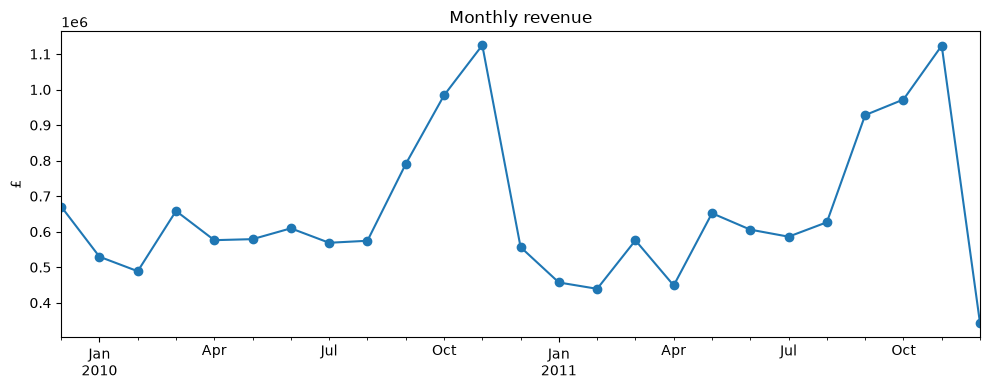

In [35]:
monthly_sales = df.set_index("InvoiceDate")["LineTotal"].resample("MS").sum()

fig, ax = plt.subplots(figsize=(10, 4))
monthly_sales.plot(ax=ax, marker="o")
ax.set_title("Monthly revenue")
ax.set_ylabel("£")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

Things to notice: the seasonality (a peak before Christmas), and the last month, which only appears to drop because the data ends on December 9, 2011. We'll take this into account for **recency** in the next notebook.

In [36]:
(df.groupby("Country")["Customer ID"].nunique()
   .sort_values(ascending=False).head(10)
   .rename("Customers"))

Country
United Kingdom    5326
Germany            107
France              93
Spain               38
Belgium             29
Switzerland         22
Netherlands         22
Portugal            22
Sweden              19
Italy               17
Name: Customers, dtype: int64

## 7. Saving

In [37]:
df.to_csv(DATA_DIR / "online_retail_clean.csv", index=False)
print("Saved:", DATA_DIR / "online_retail_clean.csv")

Saved: ..\data\online_retail_clean.csv


## Next step

`02_rfm.ipynb`: compute each customer's **Recency**, **Frequency** and **Monetary** value.